In [21]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from IPython.display import Latex, HTML, Math, display
from uncertainties import ufloat
from uncertainties.umath import sqrt
from uncertainties import unumpy as unp
from scipy.stats import linregress
from scipy.optimize import curve_fit
from uncertainties.umath import sin, radians 
from uncertainties.umath import *

/tmp/ipykernel_1145/3181570051.py:27: RuntimeWarning: invalid value encountered in log
  counts_cu = np.log(counts_cu)                               #logarithmieren für lineare darstelleung im plot/fit


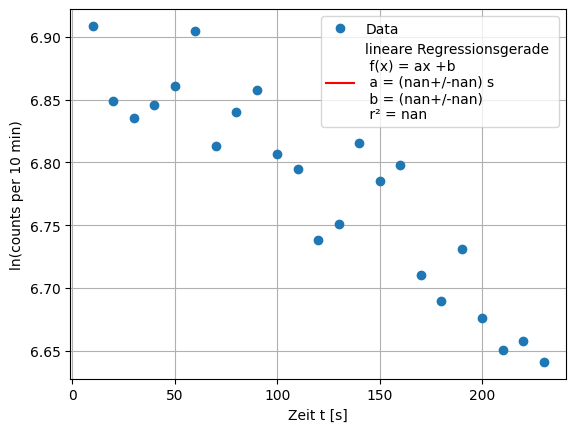

zerfallskonstante lamda: nan+/-nan
mittlere zerfallszeit tau: nan+/-nan
Halbwertszeit: nan+/-nan


In [ ]:
# 1. Radioaktiver Zerfall - Halbwertszeit von Kupfer

#Hintergrundstrahlung

hintergrund = 74                #Zählimpulse pro 10 minuten; Hintergrundstrahlung


#Halbwertszeitmessung für Kupfer

data = pd.read_csv("Cu-2026-04-30.csv", sep=",", decimal=".", engine="python")           #csv Kupferzerfall; in unserem fall ohne daten von vorherigen gruppen - evtl nach bedarf dazufügen
counts = data["counts"].to_numpy()                            #Zahl der Impulse beim Kupferzerfall
t = data["Time since 1970-01-01T00:00:00Z"].to_numpy()          #Zeit ab 01.01.1970 [s]

t_exp = np.zeros(len(t))
for i in range(len(t)):                             #Zeit ab Messstart und umrechnen in minuten [min]
    if i > 0:
        t_exp[i] = (t[i] - t[0]) / 60


counts_cu = np.zeros(len(counts))
for i in range(len(counts)):
    if i == 0:
        counts_cu[i] = counts[i] - hintergrund
    elif i > 0:
        counts_cu[i] = (counts[i] - counts[i-1]) - hintergrund           #ersetzen der absoluten zählimpulse mit den zählimpulsen pro zeiteinheit und abziehen der Hintergrundstrahlung

counts_cu = np.log(counts_cu)                               #logarithmieren für lineare darstelleung im plot/fit


#Fit und Berechnung Halbwertszeit

regression = linregress(t_exp, counts_cu)            #linearer fit couns gegen zeit 

a = ufloat(regression.slope, regression.stderr)                  #steigung mit unsicherheit
b = ufloat(regression.intercept, regression.intercept_stderr)

lam = a * (-1)                          #Zerfallskonstante lamda; -1 * Steigung aus fit [1/s]
tau = 1/lam                             #mittlere Lebensdauer [s]

T_2 = tau * np.log(2)                   #Halbwertszeit [s]


#Plot und ergebnisse printen

t_fit = np.linspace(min(t_exp), max(t_exp), 200)            #kontinuierliche t für plot erzeugen

plt.figure()
plt.plot(t_exp, counts_cu, 'o', label="Data")
plt.plot(t_fit, regression.slope*t_fit + regression.intercept, '-r', label=f"lineare Regressionsgerade \n f(x) = ax +b \n a = ({a}) min \n b = ({b}) \n r² = {regression.rvalue**2:.4f}")
plt.xlabel("Zeit t [min]")
plt.ylabel("ln(counts per 10 min)")
plt.legend()
plt.grid(True)
plt.show()


print(f"zerfallskonstante lamda: {lam}")
print(f"mittlere zerfallszeit tau: {tau}")
print(f"Halbwertszeit: {T_2}")


/tmp/ipykernel_1145/3498030319.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


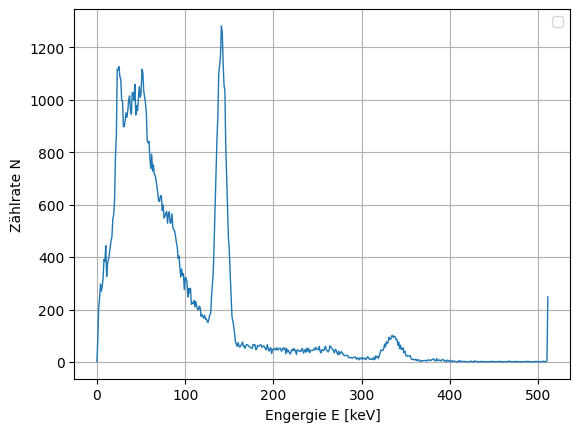

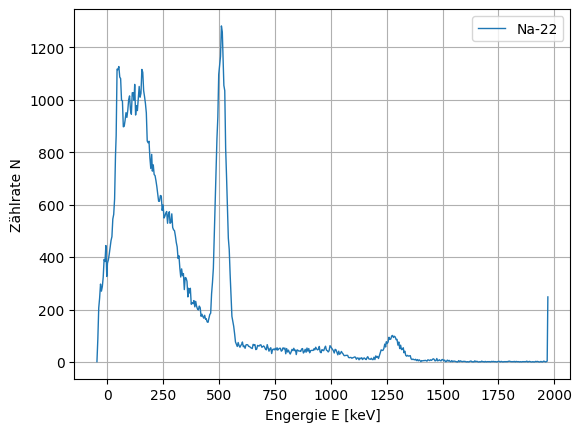

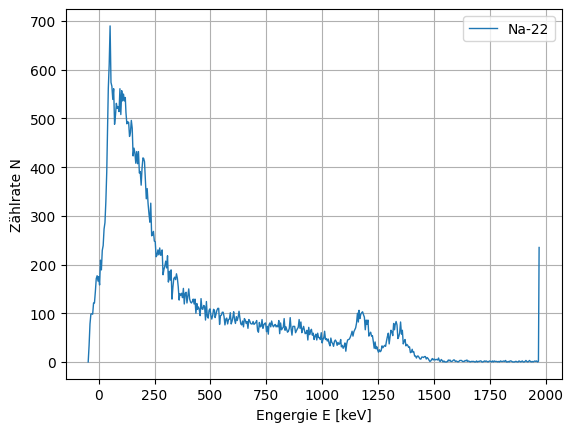

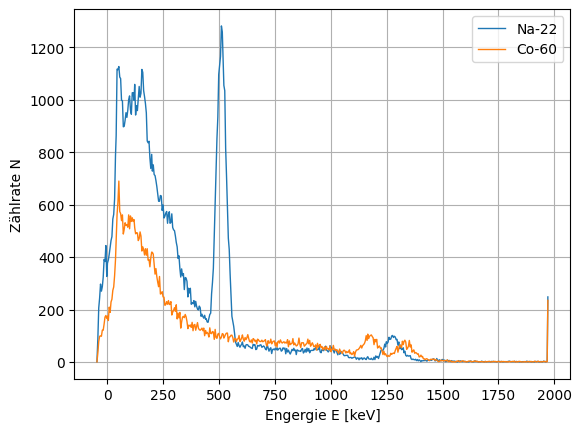

Probe: Co-60


In [23]:
# 2. Grundlagen der Beta- und Gammaspektroskopie

#Werte
# x = ufloat(, )              #Abstand der Probenhalterung [mm]
# d = x - 1                   #Abstand Probe zum Szintillator [mm] 

#Energiespektrum Na-22 unkalibriet
U = 754             #[kV] Versorgungsspannung

Na_unkalibriert = pd.read_excel("Do01_Na22_754.ods", engine="odf")         #ods datei natrium spektrum
E_unkalibriert = Na_unkalibriert["n_A"].to_numpy()               #Energie aus ods [keV]
N_unkalibriert = Na_unkalibriert["N_A"].to_numpy()               #Zählrate aus ods

plt.figure()
plt.plot(E_unkalibriert, N_unkalibriert, '-', linewidth=1, label="")
plt.xlabel("Engergie E [keV]")
plt.ylabel("Zählrate N")
plt.legend()
plt.grid(True)
plt.show()

#Energiespektrum Na-22 kalibriert
U = 754             #[V] Versorgungsspannung

Na_750 = pd.read_excel("Do01_Na22_754.ods", engine="odf")         #ods datei natrium spektrum 750V
E_750 = Na_750["E_A / keV"].to_numpy()               #Energie aus ods [keV]
N_750 = Na_750["Unnamed: 4"].to_numpy()               #Zählrate aus ods

plt.figure()
plt.plot(E_750, N_750, '-', linewidth=1, label="Na-22")
plt.xlabel("Engergie E [keV]")
plt.ylabel("Zählrate N")
plt.legend()
plt.grid(True)
plt.show()

#Energiespektrum unbekannte Probe
U = 750             #[V] Versorgungsspannung

probe = pd.read_excel("Do01_unbekannt_754.ods")          #ods unbekannte probe 750V
E = probe["E_A / keV"].to_numpy()                    #Energie aus ods [keV]
N = probe["Unnamed: 1"].to_numpy()                    #Zählrate aus ods

plt.figure()
plt.plot(E, N, '-', linewidth=1, label="Na-22")
plt.xlabel("Engergie E [keV]")
plt.ylabel("Zählrate N")
plt.legend()
plt.grid(True)
plt.show()

#gemeinsamer plot zum vergelich

plt.figure()
plt.plot(E_750, N_750, '-', linewidth=1, label="Na-22")
plt.plot(E, N, '-', linewidth=1, label="Co-60")
plt.xlabel("Engergie E [keV]")
plt.ylabel("Zählrate N")
plt.legend()
plt.grid(True)
plt.show()


print("Probe: Co-60")

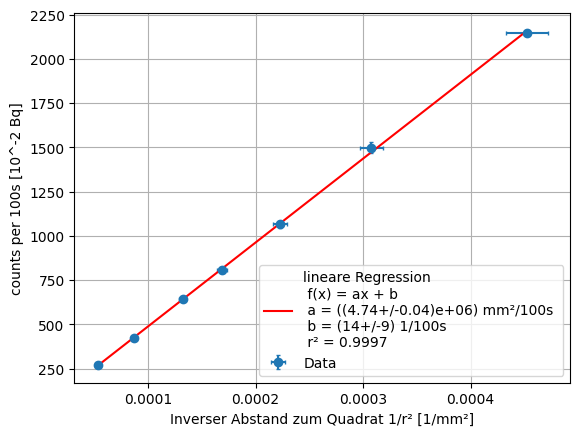

In [49]:
# 3. Abstandsgesetz für punktförmige Strahler

#Werte
r = unp.uarray([47, 57, 67, 77, 87, 107, 137], 1)        #[mm] Abstand zwischen Probenhalterung und Detektorhalterung für alle bis auf die 2 nächsten Löcher = Abstand Probe-Detektor

x = 1 / r**2                #umrechnung von r auf x um linearen zusammenhang zu bekommen. [1/mm²?]

count1 = np.mean(np.array([2112, 2179, 2152]))                       #[100 Bq] Zählimpulse pro 100s für Abstände 1-7
count2 = np.mean(np.array([1474, 1575, 1444]))
count3 = np.mean(np.array([1102, 1017, 1075]))
count4 = np.mean(np.array([768, 823, 833]))
count5 = np.mean(np.array([643, 624, 655]))
count6 = np.mean(np.array([416, 426, 428]))
count7 = np.mean(np.array([263, 265, 274]))

counts_u1 = np.std(np.array([2112, 2179, 2152]))/np.sqrt(3)
counts_u2 = np.std(np.array([1474, 1575, 1444]))/np.sqrt(3)
counts_u3 = np.std(np.array([1102, 1017, 1075]))/np.sqrt(3)
counts_u4 = np.std(np.array([768, 823, 833]))/np.sqrt(3)
counts_u5 = np.std(np.array([643, 624, 655]))/np.sqrt(3)
counts_u6 = np.std(np.array([416, 426, 428]))/np.sqrt(3)
counts_u7 = np.std(np.array([263, 265, 274]))/np.sqrt(3)

counts = np.array([count1, count2, count3, count4, count5, count6, count7])       #[100 Bq] Zählimpulse pro 100s für jedes der Löcher
counts_u = np.array([counts_u1, counts_u2, counts_u3, counts_u4, counts_u5, counts_u6, counts_u7])


#Fit
x_nom = unp.nominal_values(x)       #nomimalwerte für fit
x_err = unp.std_devs(x)

reg = linregress(x_nom, counts)         #lineare regression
a = ufloat(reg.slope, reg.stderr) 
b = ufloat(reg.intercept, reg.intercept_stderr)

#Plot
x_plot = np.linspace(min(x_nom), max(x_nom), 200)

plt.figure()
plt.errorbar(x_nom, counts, xerr=x_err,yerr=counts_u, fmt='o', capsize=1.5, label="Data")
plt.plot(x_plot, x_plot*reg.slope + reg.intercept, '-r', label=f"lineare Regression \n f(x) = ax + b \n a = ({a}) mm²/100s \n b = ({b}) 1/100s \n r² = {reg.rvalue**2:.4f}")
plt.xlabel("Inverser Abstand zum Quadrat 1/r² [1/mm²]")
plt.ylabel(rf"counts per 100s [10^-2 Bq]")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
# 4. Reichweite von Alphastrahlen in Luft

#foto von nebelkammer; d = 10 mm Durchmesser Metallstab zur Bestimmung der Länge der Nebelspur

u = ufloat(156, 10)/10                 #umrechnungsfaktor [px]; so viele px sind 1 mm

#r_px = np.array([np.sqrt(419**2 + 461**2), np.sqrt(296**2 + 530**2), np.sqrt(122**2 + 690**2), np.sqrt(52**2 + 679**2), np.sqrt(298**2 + 566**2), np.sqrt(395**2 + 525**2), np.sqrt(144**2 + 670**2)])          #gemessener Abstand aus Nebelkammer [px]; geschätzt im Foto
r_px = np.array([np.sqrt(410**2 + 463**2), np.sqrt(293**2 + 524**2), np.sqrt(203**2 + 581**2), np.sqrt(89**2 + 645**2), np.sqrt(57**2 + 668**2), np.sqrt(381**2 + 491**2), np.sqrt(279**2 + 553**2)])          #gemessener Abstand aus Nebelkammer [px]; geschätzt im Foto
r_px_mean = np.mean(r_px)
r_px_std = np.std(r_px) / np.sqrt(len(r_px))
r_px_u = ufloat(r_px_mean, r_px_std)
print(r_px)
print(r_px_u)

r_mm = r_px_u / u                       #umrechenen [px] --> [mm]
print(f"Abstand r: {r_mm} [mm]")

E = (r_mm/3.1)**(2/3)      #Energie der Alphastrahlen [MeV]
print(f"Energie: {E} [MeV]")
print("Literatur: 4.87 [MeV]")


[618.44078132 600.3540622  615.44292993 651.1113576  670.42747557
 621.48370856 619.39486598]
628+/-8
Abstand r: 40.3+/-2.6 [mm]
Energie: 5.53+/-0.24 [MeV]
